# League Trade History

`report trades` turns a league's stored trade history into ten PNGs -- who trades, who trades with whom, and how that's changed over time. Mirrors the [League Trade History](https://nolmacdonald.github.io/nuclearff/league_trade_history.html) docs page, grounded in one real league's real data (`1367225133634191360`, `NUCLEARFF REDRAFT`): 22 completed trades since 2021, across the 15 managers who have ever held a roster in the league.

This is the same `sleeper_transactions` table `sleeper fetch-league --transactions` writes -- see `01_user_guide.ipynb`'s "Transaction history" section if you haven't fetched it yet. No new fetching happens here; this command only reads and renders what's already stored.

By default (`--all-users` not passed) this command only includes managers currently rostered in `league_id`'s own season -- 10 of this league's real 15 all-time managers. Since this notebook is specifically a full historical walkthrough, the command below passes `--all-users` to include all 15; drop the flag for a leaner, current-roster-only view instead.

## Fetching the full trade history

This notebook is self-contained: it doesn't assume `01_user_guide.ipynb`'s `--transactions --max-week 3` illustration already ran (and that partial fetch wouldn't have this league's real full 22-trade history anyway -- it only covers each season's first 3 weeks). Fetch every transaction across the whole chain, plus `--standings` for the full manager roster (`--all-users` below needs it -- without it, a manager with zero trades has no way to be known about at all).

In [1]:
!uv run nuclearff --root ./demo sleeper fetch-league --league-id 1367225133634191360 --transactions --standings

2026-09-09T23:18:41 [INFO] nuclearff.sleeper.standings: Wrote 60 standings row(s) and 66 playoff match row(s) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb


2026-09-09T23:18:58 [INFO] nuclearff.sleeper.transactions: Wrote 1762 transaction(s) and 2674 transaction-player row(s) to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/cache/nuclearff.duckdb
2026-09-09T23:18:58 [INFO] nuclearff.sleeper.snapshot: Wrote Sleeper snapshot to /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061837Z
League:   NUCLEARFF REDRAFT (1367225133634191360)
Season:   2026 status=in_season
Teams:    10
Snapshot: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/raw/sleeper/1367225133634191360/20260910T061837Z
League config: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/configs/leagues/1367225133634191360.yaml

Settings to review:
  [WARNING] draft_rounds_mismatch: League settings report draft_rounds=3 but the draft object reports rounds=15.
           -> Trust the draft object. The league field is stale; use 15 rounds for pick-gap and VONA math.
  [WARNING] keepers_in

## Running the command

In [2]:
!uv run nuclearff --root ./demo report trades 1367225133634191360 --all-users

2026-09-09T23:18:59 [INFO] nuclearff.report.trades: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/trades_by_manager.png (15 managers)


2026-09-09T23:18:59 [INFO] nuclearff.report.trades: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/trades_heatmap.png (15 managers)


2026-09-09T23:19:00 [INFO] nuclearff.report.trades: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/trade_network.png (15 managers, 13 edges)


2026-09-09T23:19:00 [INFO] nuclearff.report.trades: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/trade_leaderboard.png (15 managers)


2026-09-09T23:19:00 [INFO] nuclearff.report.trades: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/manager_pair_leaderboard.png (10 pairs)


2026-09-09T23:19:00 [INFO] nuclearff.report.trades: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/trades_over_time.png (15 managers, 6 seasons)


2026-09-09T23:19:00 [INFO] nuclearff.report.trades: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/manager_season_heatmap.png (15 managers, 6 seasons)


2026-09-09T23:19:01 [INFO] nuclearff.report.trades: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/cumulative_trades.png (10 managers)


2026-09-09T23:19:01 [INFO] nuclearff.report.trades: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/trade_partner_diversity.png (15 managers)


2026-09-09T23:19:01 [INFO] nuclearff.report.trades: Wrote /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/chord_diagram.png (15 managers)
Managers:                 15
Trades by manager:        /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/trades_by_manager.png
Trades heatmap:           /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/trades_heatmap.png
Trade network:            /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/trade_network.png
Trade leaderboard:        /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/trade_leaderboard.png
Manager-pair leaderboard: /Users/nmacdonald/projects/sandbox/nuclearff/examples/demo/data/artifacts/1367225133634191360-trades/manager_pair_leaderboard.png
Manager x season heatmap: /Users/nm

`nolmacdonald` (14 trades) is this league's most active trader by a wide margin; five managers have never made one. `--out-dir` overrides the default output location.

## Trades by manager

A horizontal bar chart, one bar per manager, sorted highest first. A manager's bar counts **distinct trades, not trade relationships** -- Sleeper allows more than two rosters in a single trade, and this league has a real one: a 2022 three-team trade among `casitzmann`, `nolmacdonald`, and `nolanmacdonald`. Each of those three managers' bars counts it once, not twice, even though it touches two other managers each.

A manager needs a resolvable Sleeper display name to appear at all. Two of this league's 22 real trades have a roster whose owner isn't in that season's user list -- a real (if rare) Sleeper data inconsistency, not a bug here -- so neither trade contributes to any manager's count.

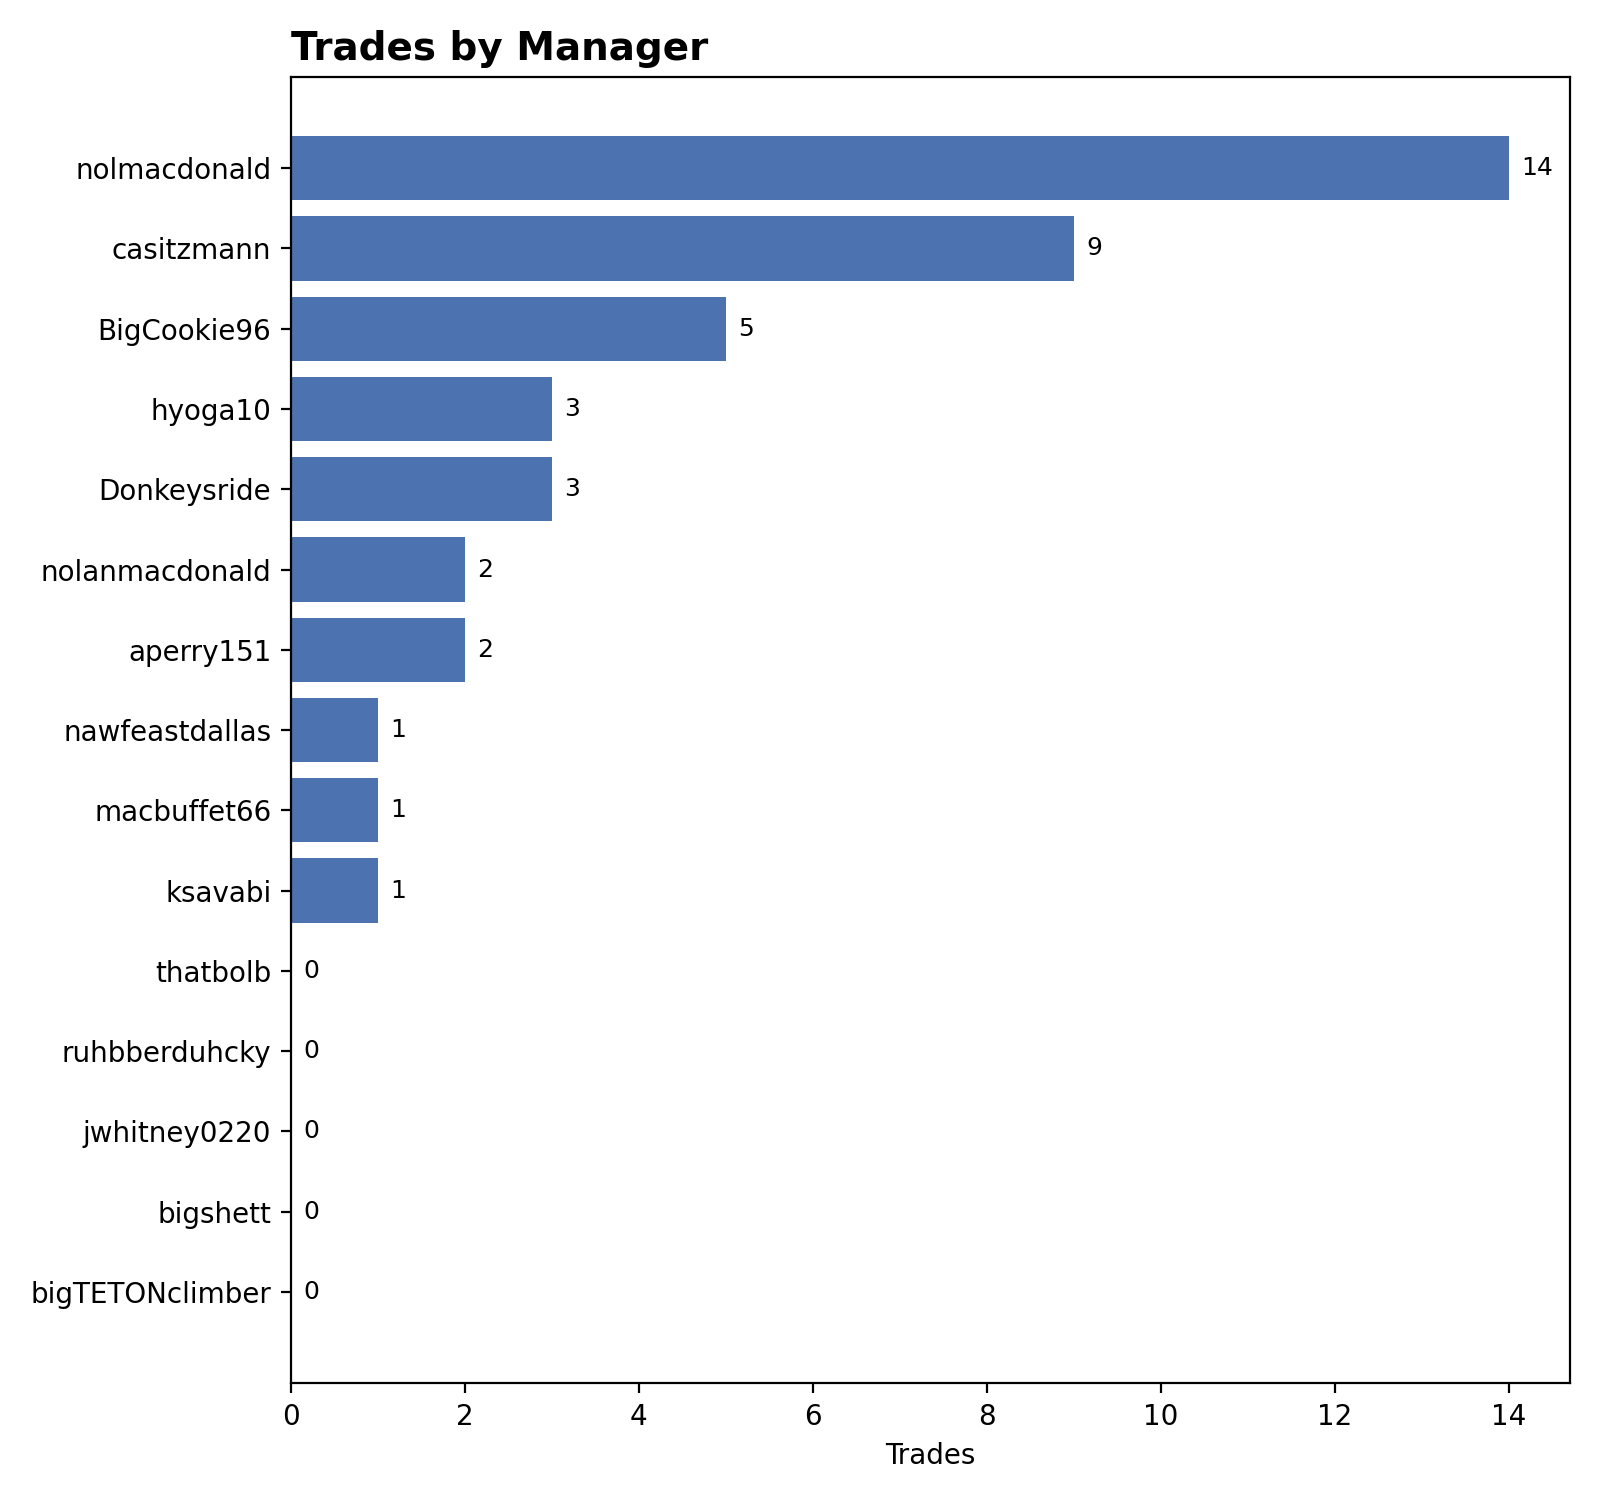

In [3]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/trades_by_manager.png"
    )
)  # Total trades per manager

## Trades between managers

A manager x manager heatmap, symmetric by construction -- trades between `casitzmann` and `nolmacdonald` show as `4` in both directions -- with a `0` diagonal, since a manager can't trade with themselves. The three-team trade above lands as one `+1` for each of the three pairs it touches, not counted twice for any single pair.

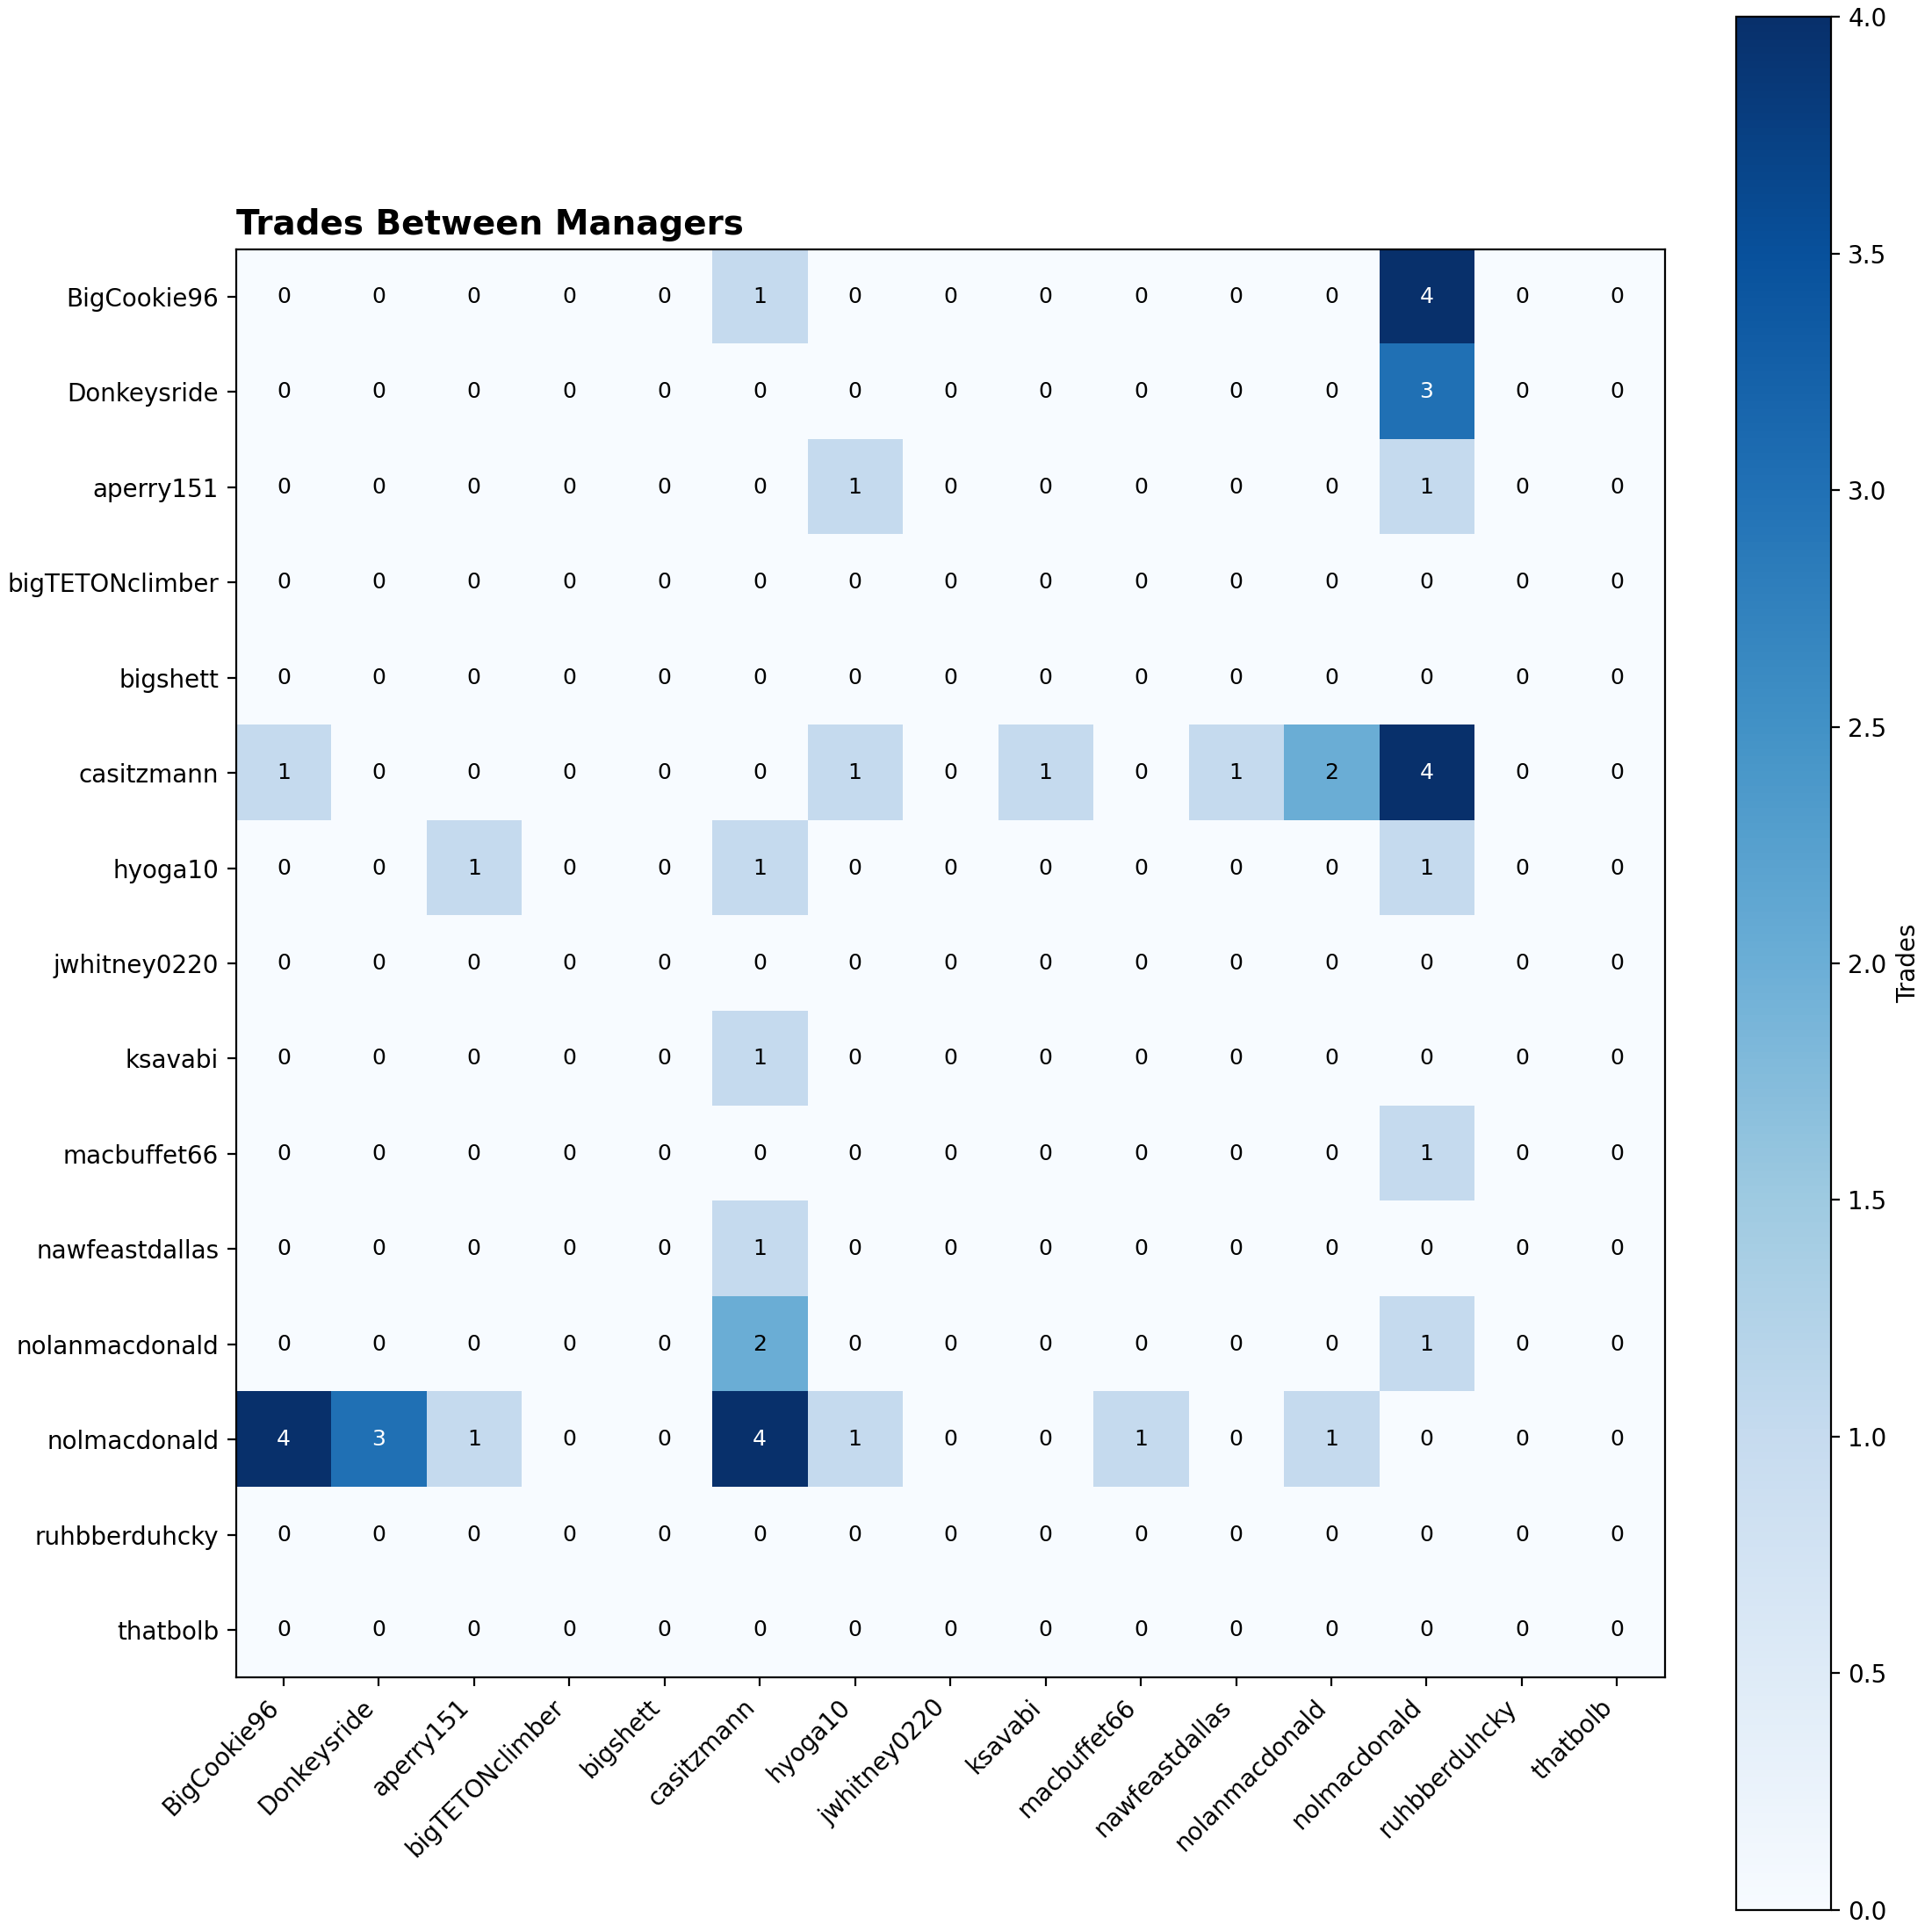

In [4]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/trades_heatmap.png"
    )
)  # Manager x manager trade heatmap

## Manager trade network

A node-link graph: one node per manager (sized by their total trades), one edge per manager pair that has traded (widened by the trade count between that pair). With only 22 trades across 15 managers, the graph is genuinely sparse -- this league's real graph has 13 edges across 15 nodes, and several managers never connect to the rest of the league at all. That's this league's real trading activity, not a rendering bug.

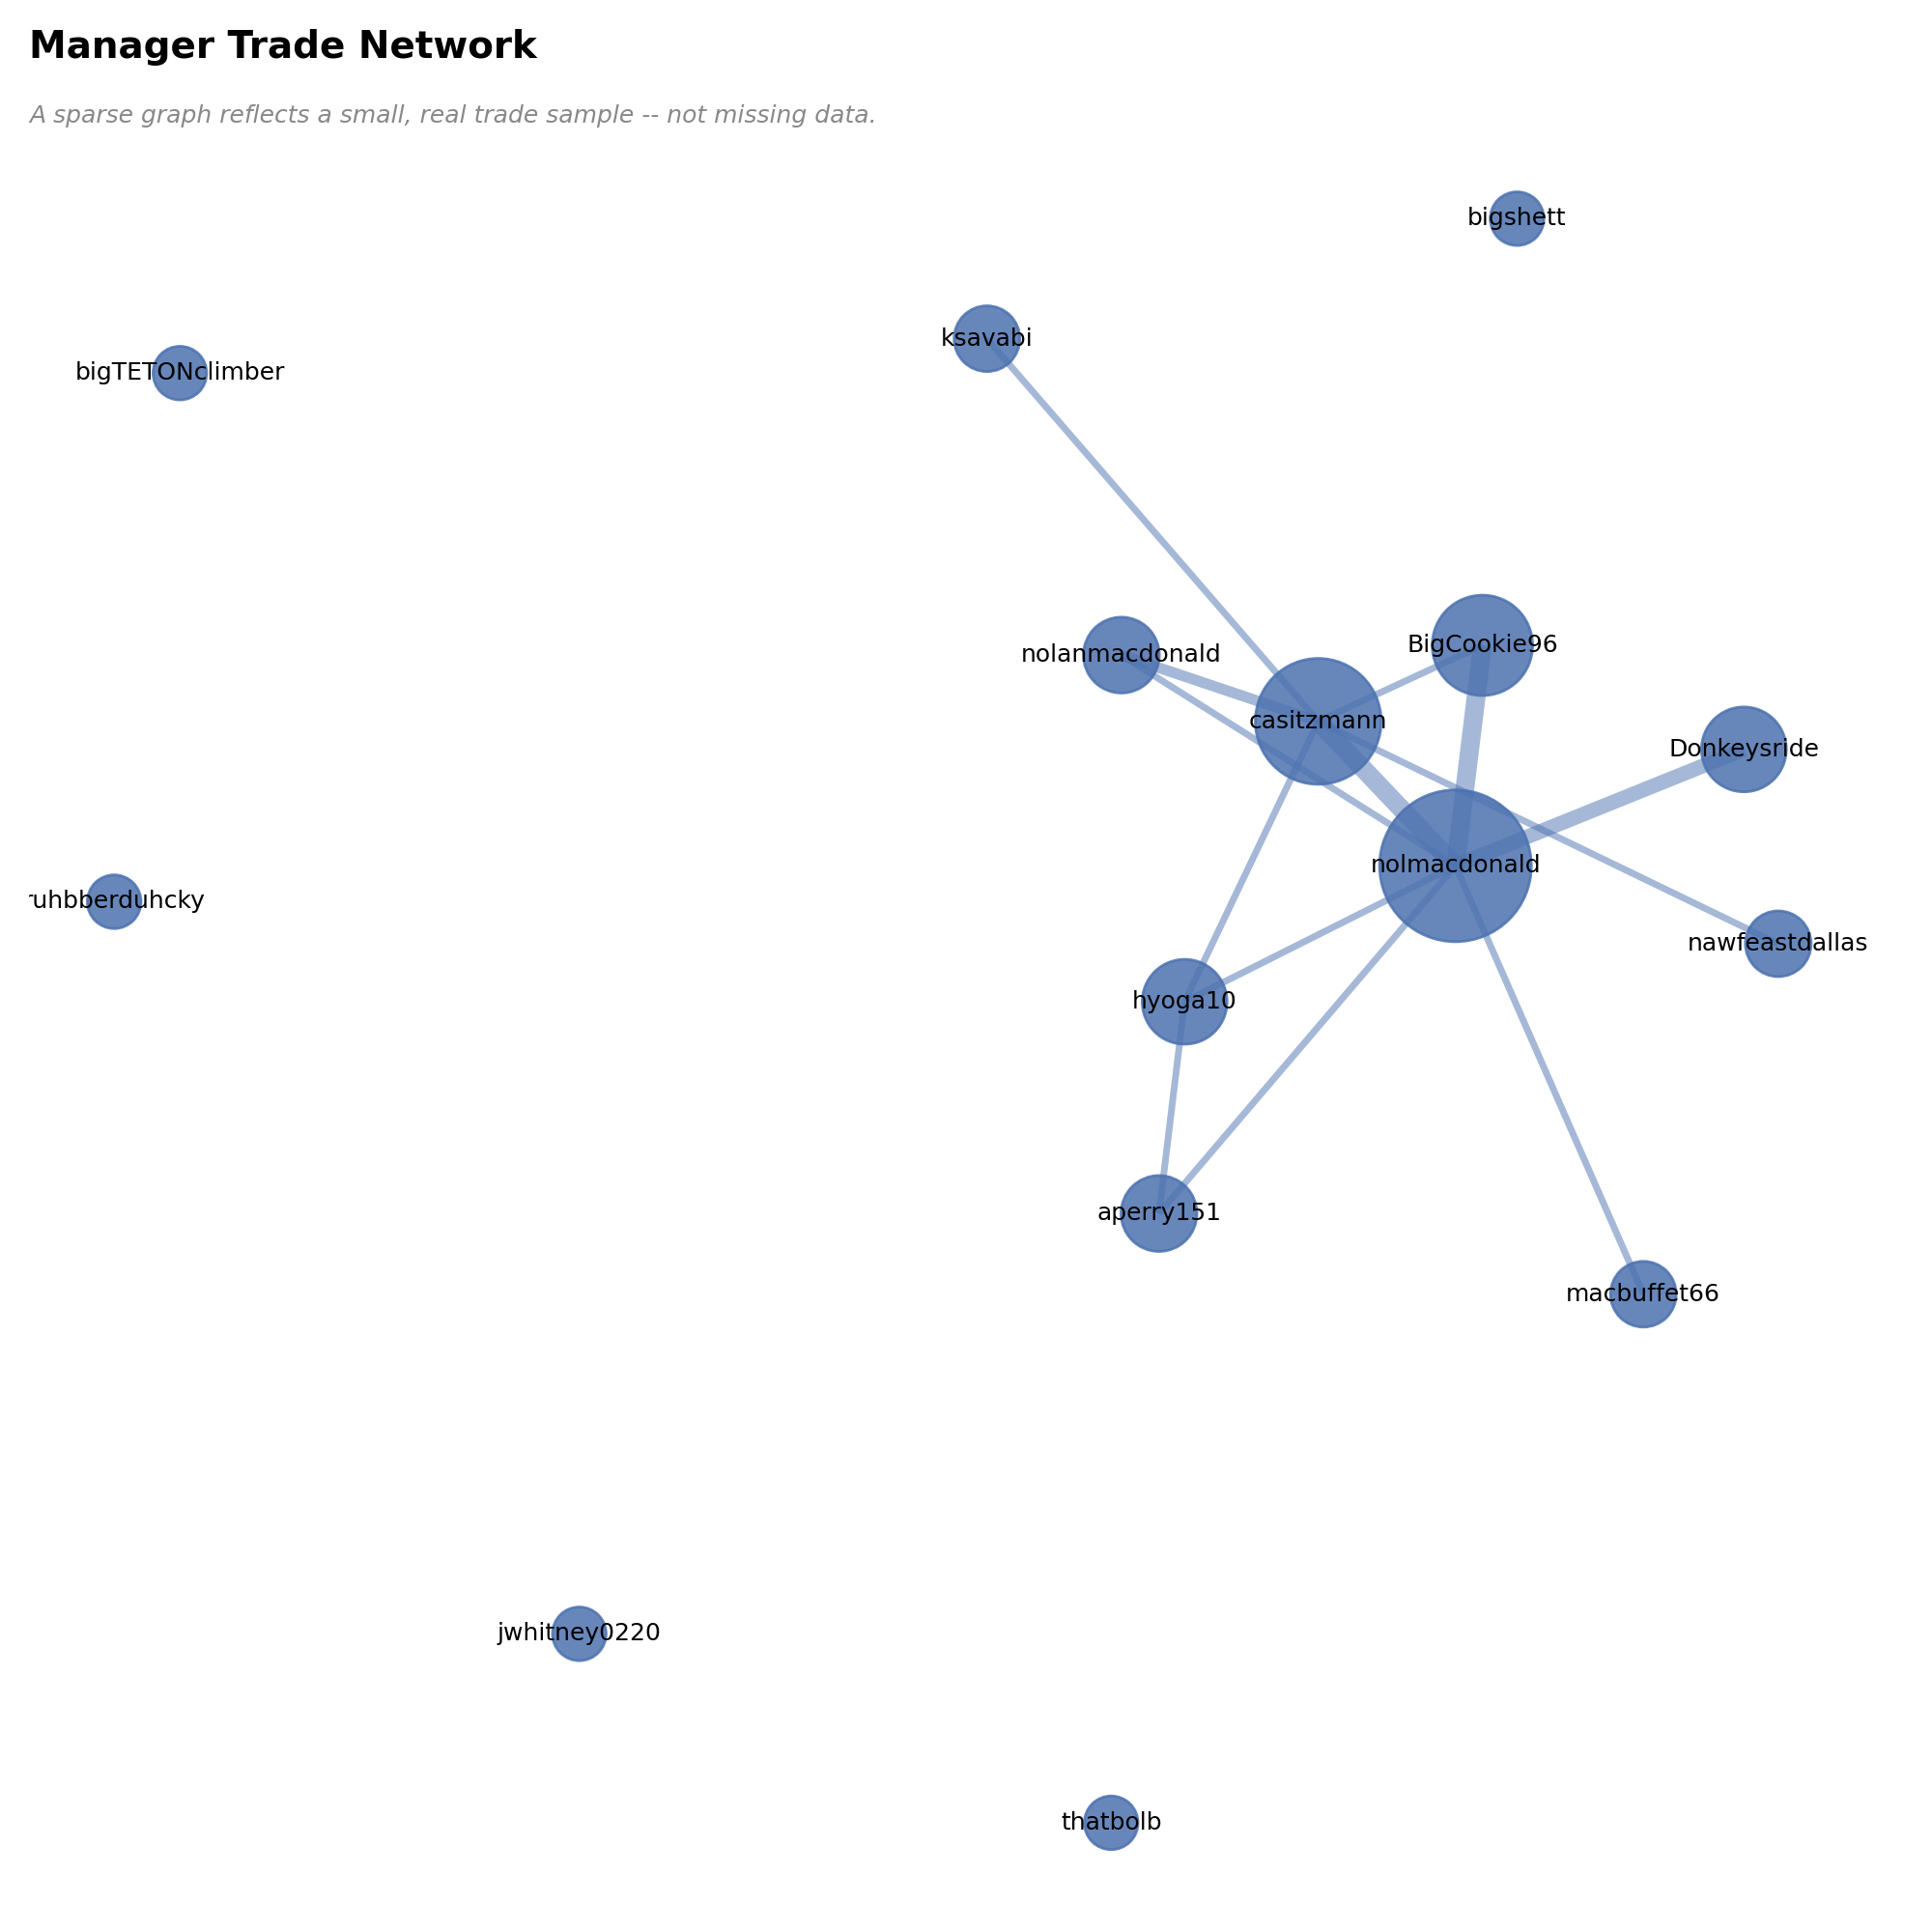

In [5]:
from IPython.display import Image, display

display(
    Image(filename="./demo/data/artifacts/1367225133634191360-trades/trade_network.png")
)  # Manager trade network graph

## Chord diagram

A more presentation-oriented view of the same relationships as the network graph: managers sit evenly spaced on a circle, each pair with at least one trade joined by a curved arc widened by trade count. Node size still tracks total trades, so `nolmacdonald` is both the largest node and the center of the widest arcs.

Drawn directly in matplotlib rather than through an interactive plotting library -- every other visualization on this page is a static PNG, and keeping this one the same avoids adding a headless-browser dependency for a single chart.

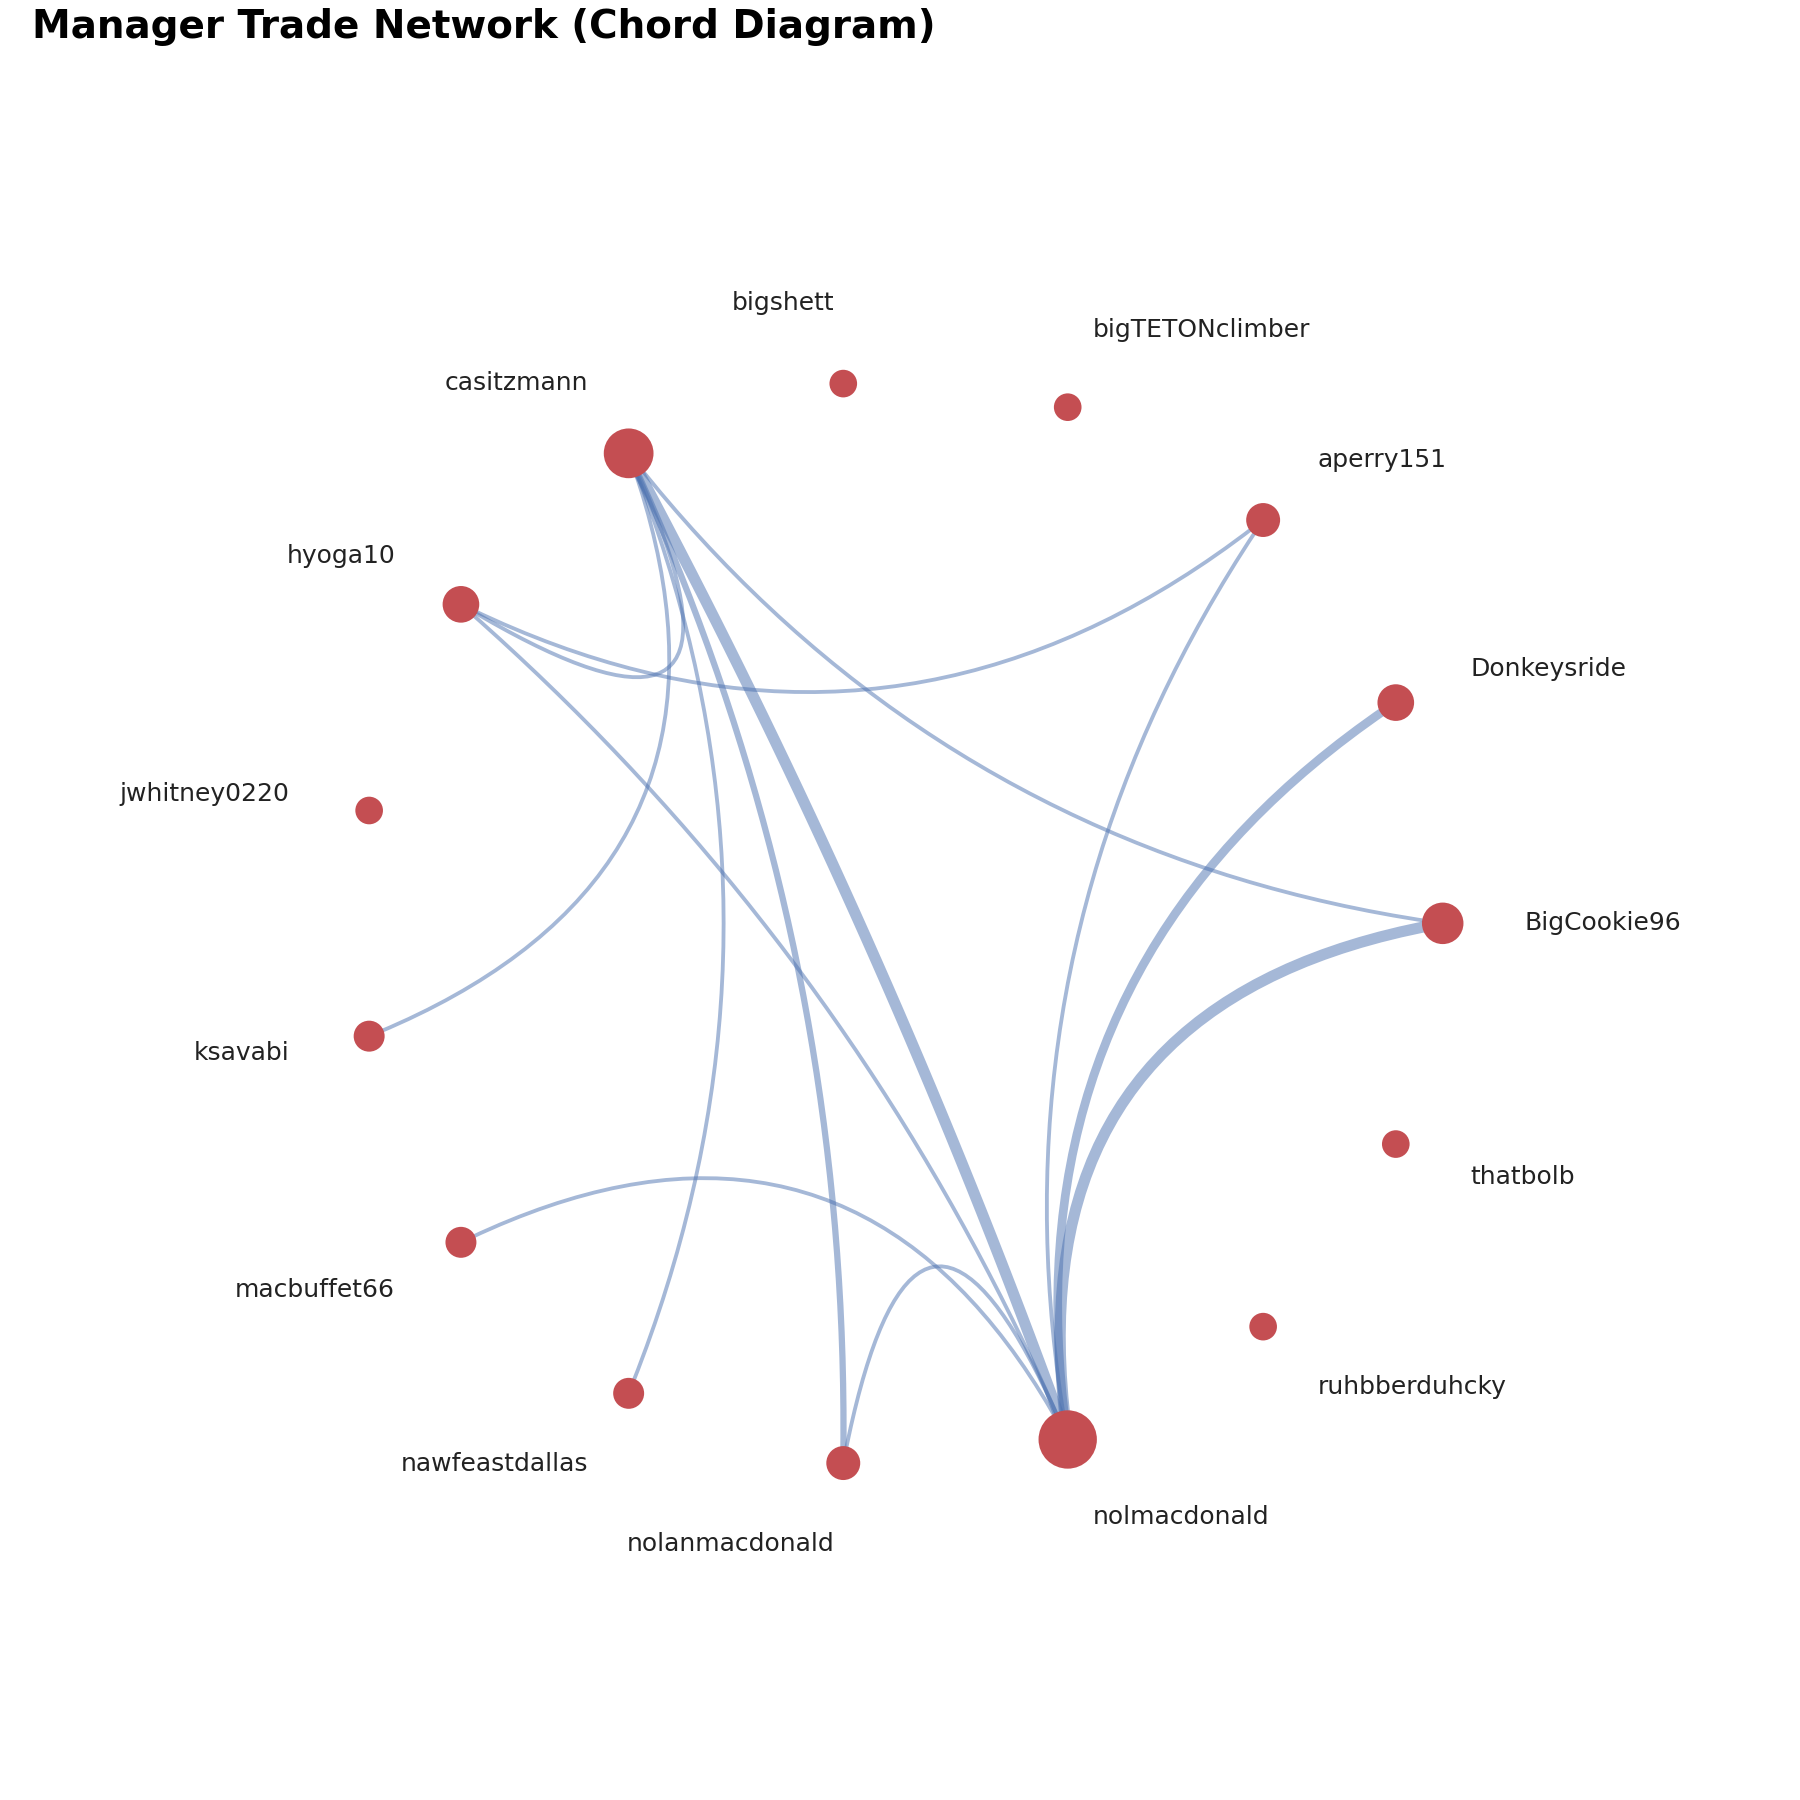

In [6]:
from IPython.display import Image, display

display(
    Image(filename="./demo/data/artifacts/1367225133634191360-trades/chord_diagram.png")
)  # Circular chord diagram

## Trade leaderboard table

One reference row per manager -- Trades, Unique Partners, Most Frequent Partner, Trades With Partner -- sorted by trade count, most active first. A zero-trade manager still gets a full row rather than being omitted, with `—` in place of a partner that doesn't exist.

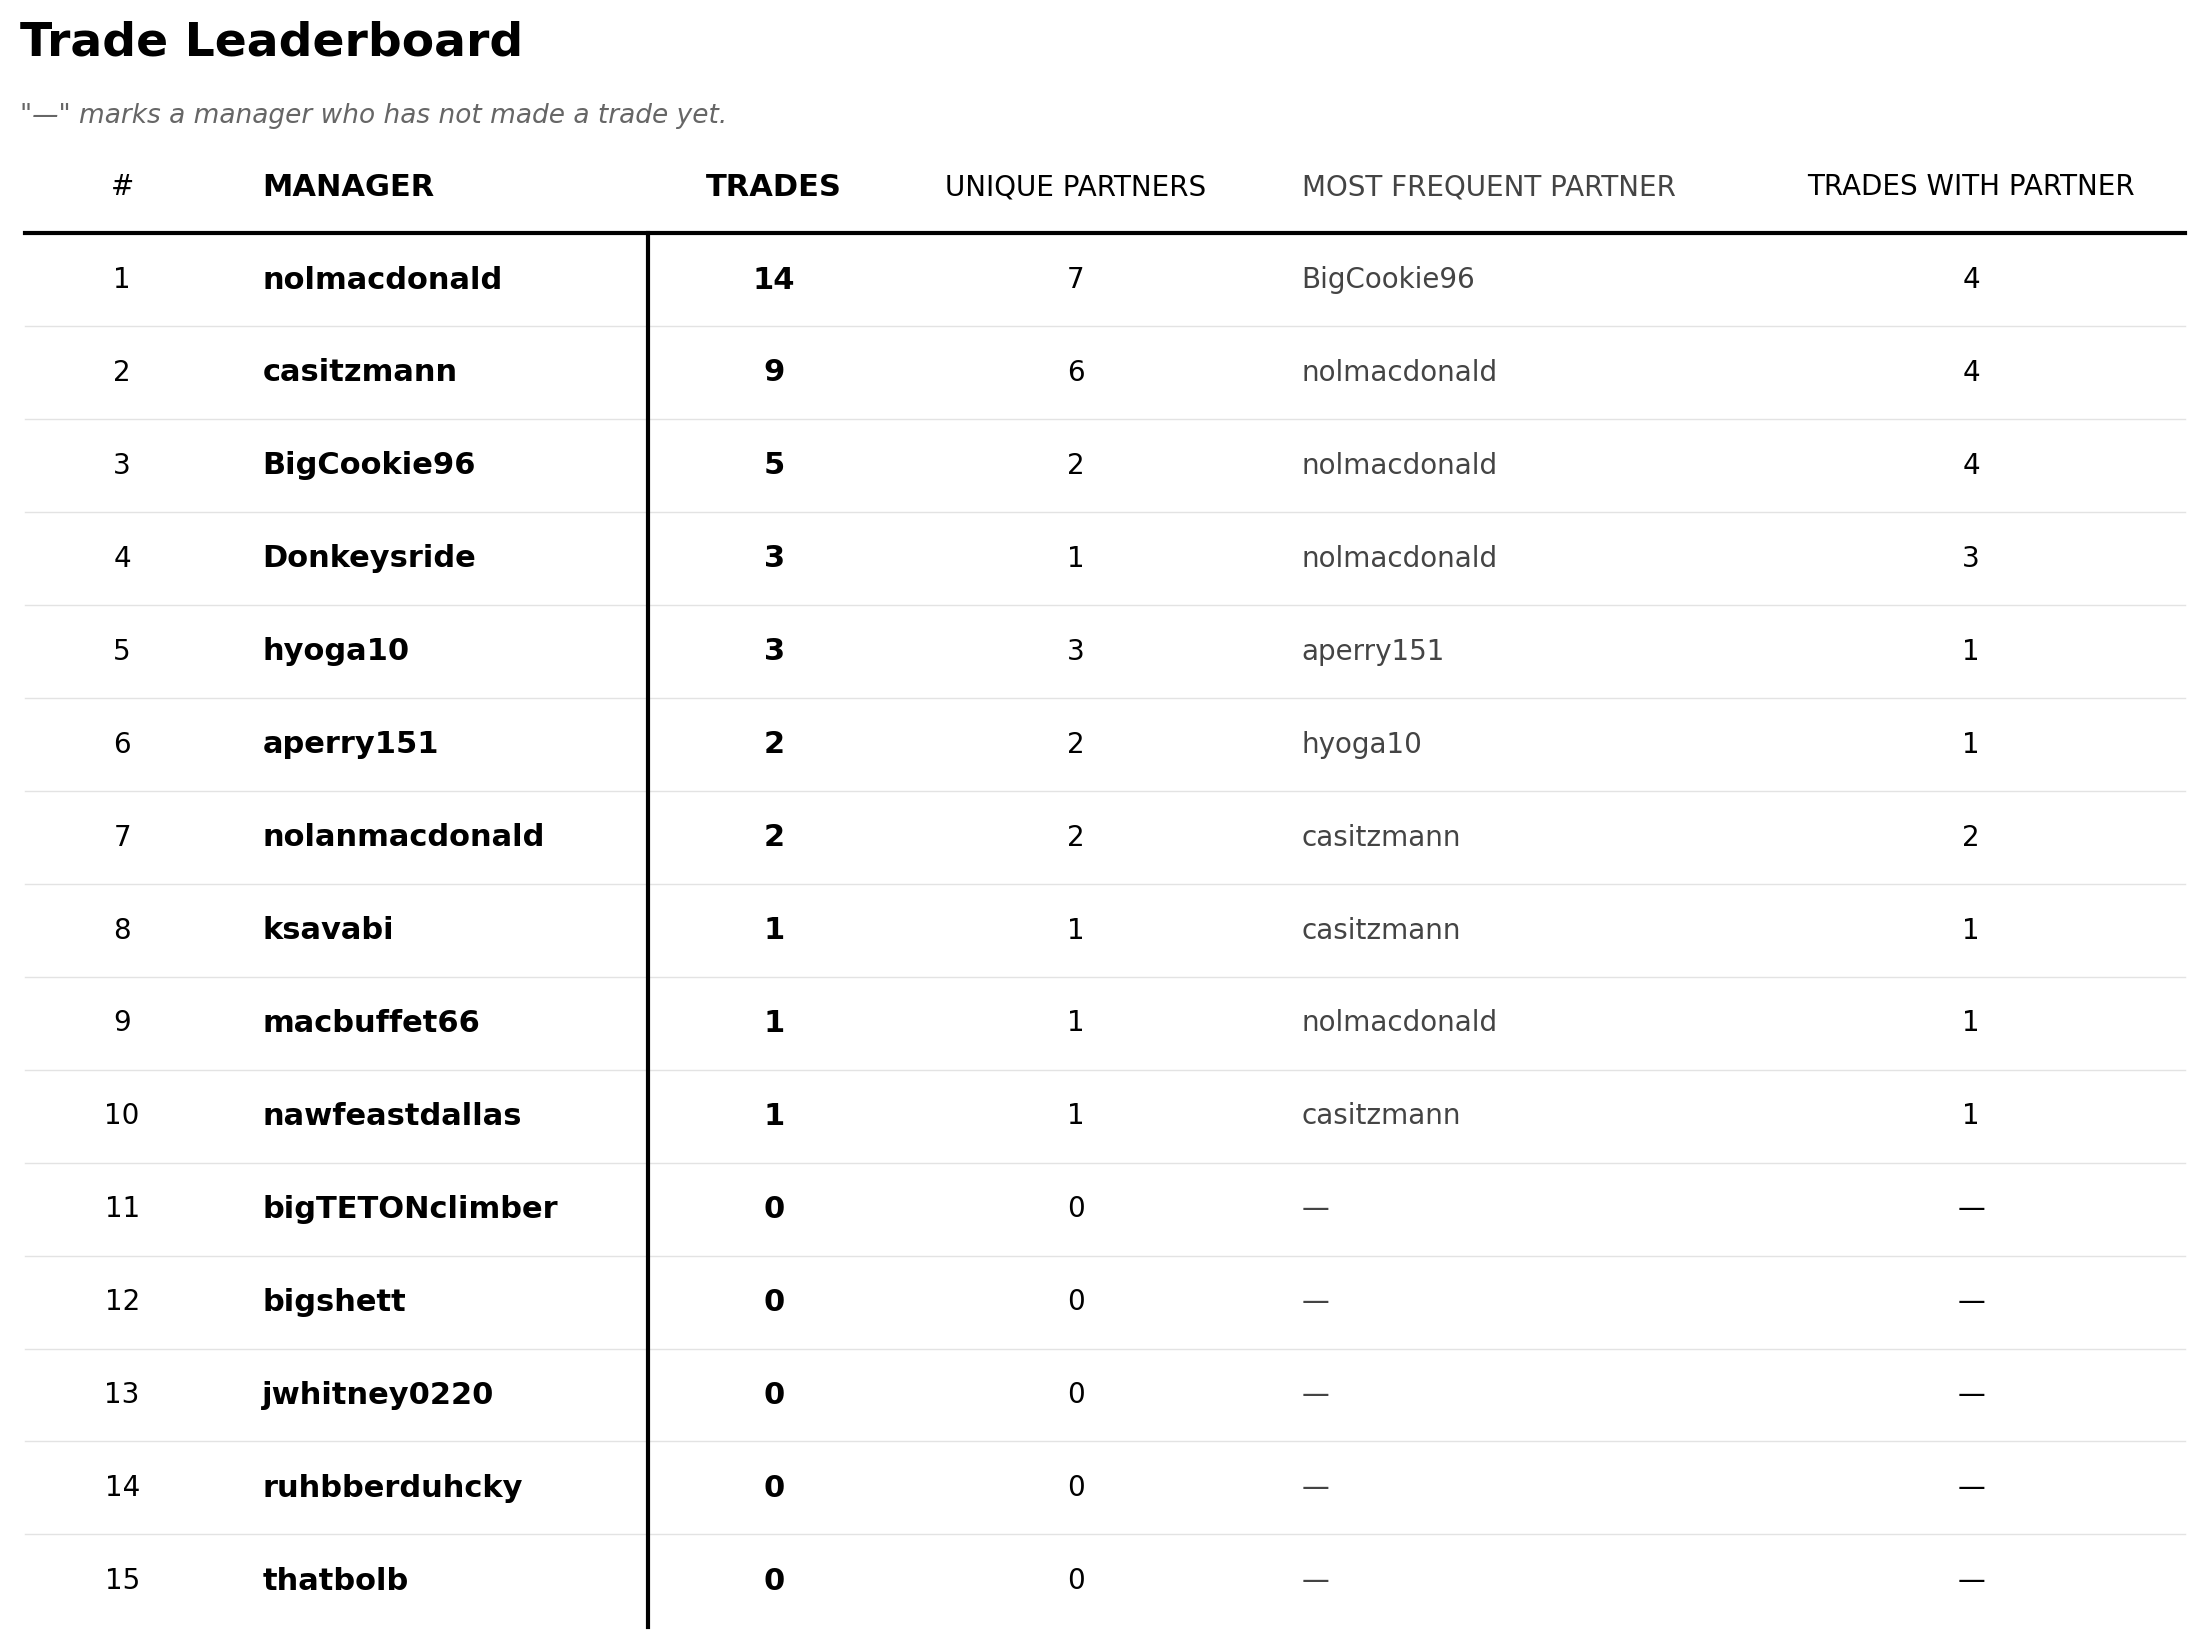

In [7]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/trade_leaderboard.png"
    )
)  # Trade leaderboard table

## Manager-pair leaderboard

A horizontal bar chart of the top 10 manager pairs by trade count, labeled `Manager A ↔ Manager B`. Unlike the heatmap it only shows pairs that actually traded -- with a real 22-trade history, that's 10 pairs across 15 managers, most tied at a single trade.

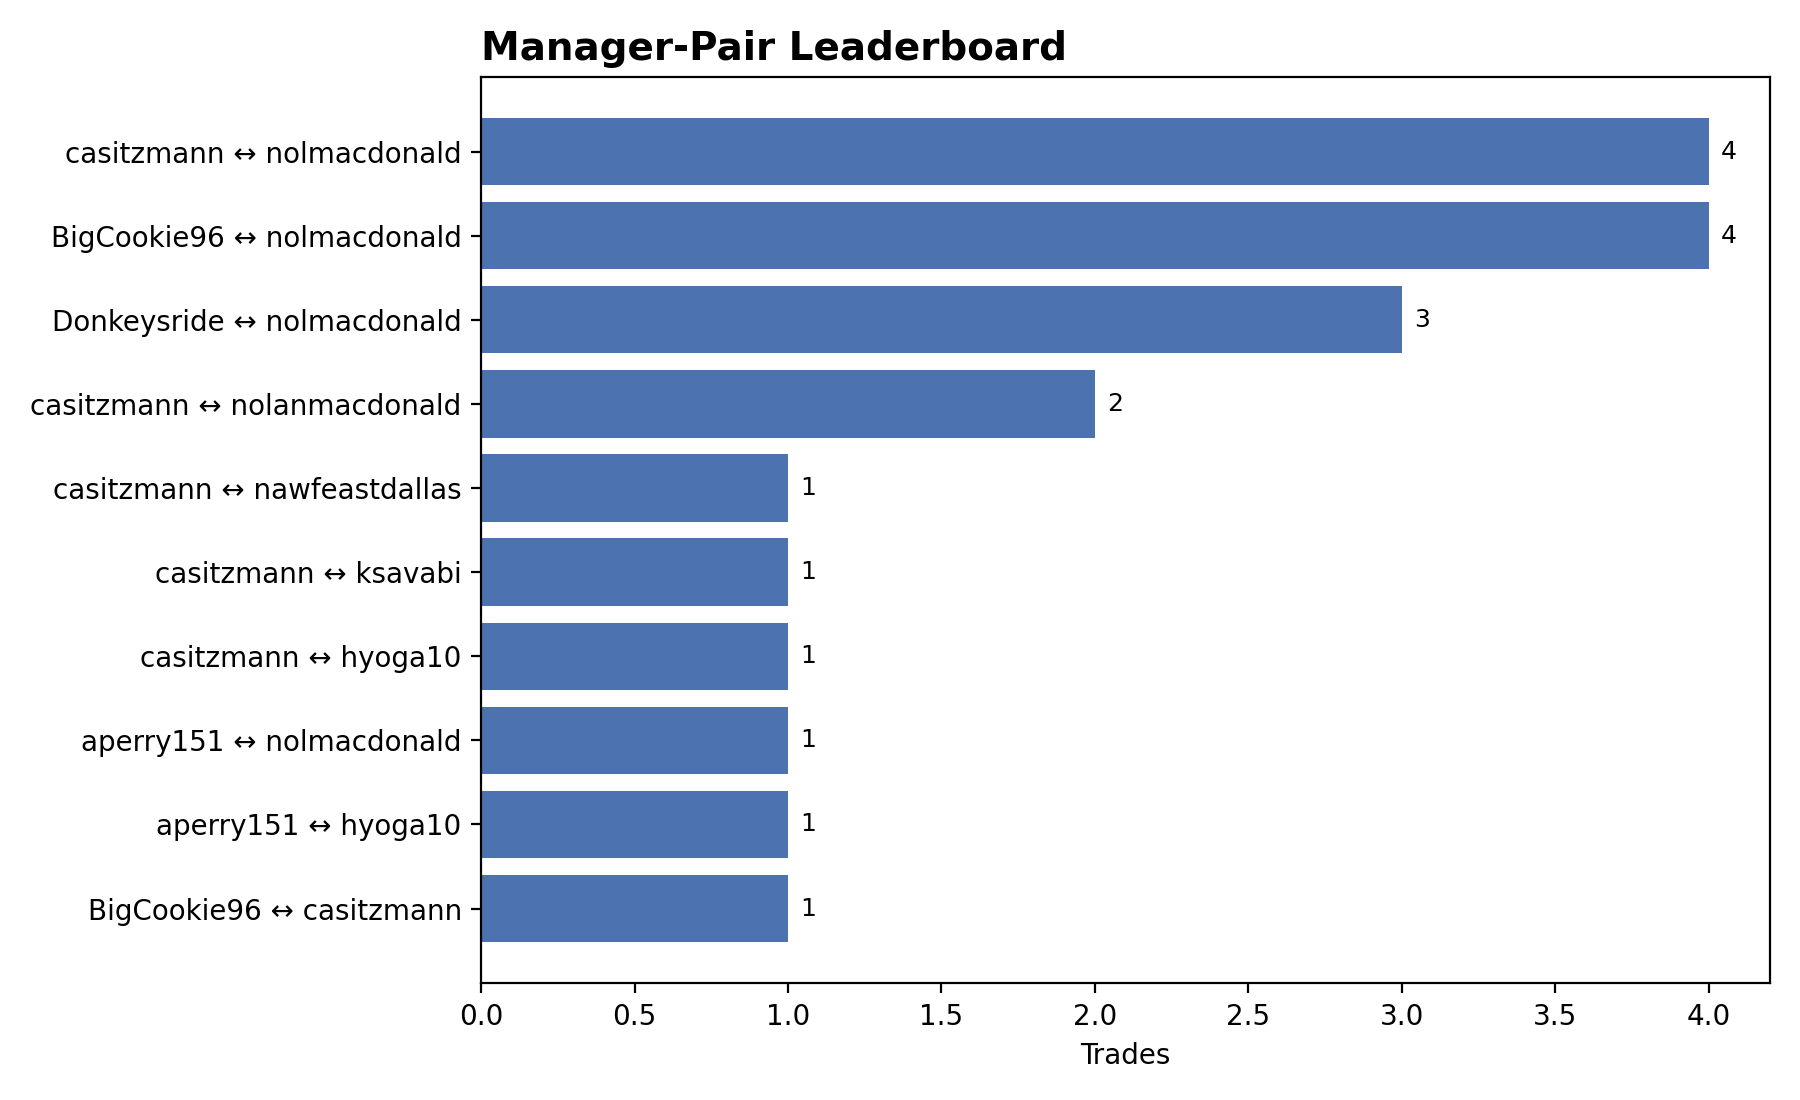

In [8]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/manager_pair_leaderboard.png"
    )
)  # Top manager pairs by trade count

## Trades over time

One thin line per manager plus a bold league-wide total line, by season. A manager's line covers only the seasons `sleeper_standings` shows them actually rostering. The league total counts each trade once regardless of how many managers it involved -- summing every manager's own line instead would roughly double-count a season's real trade volume.

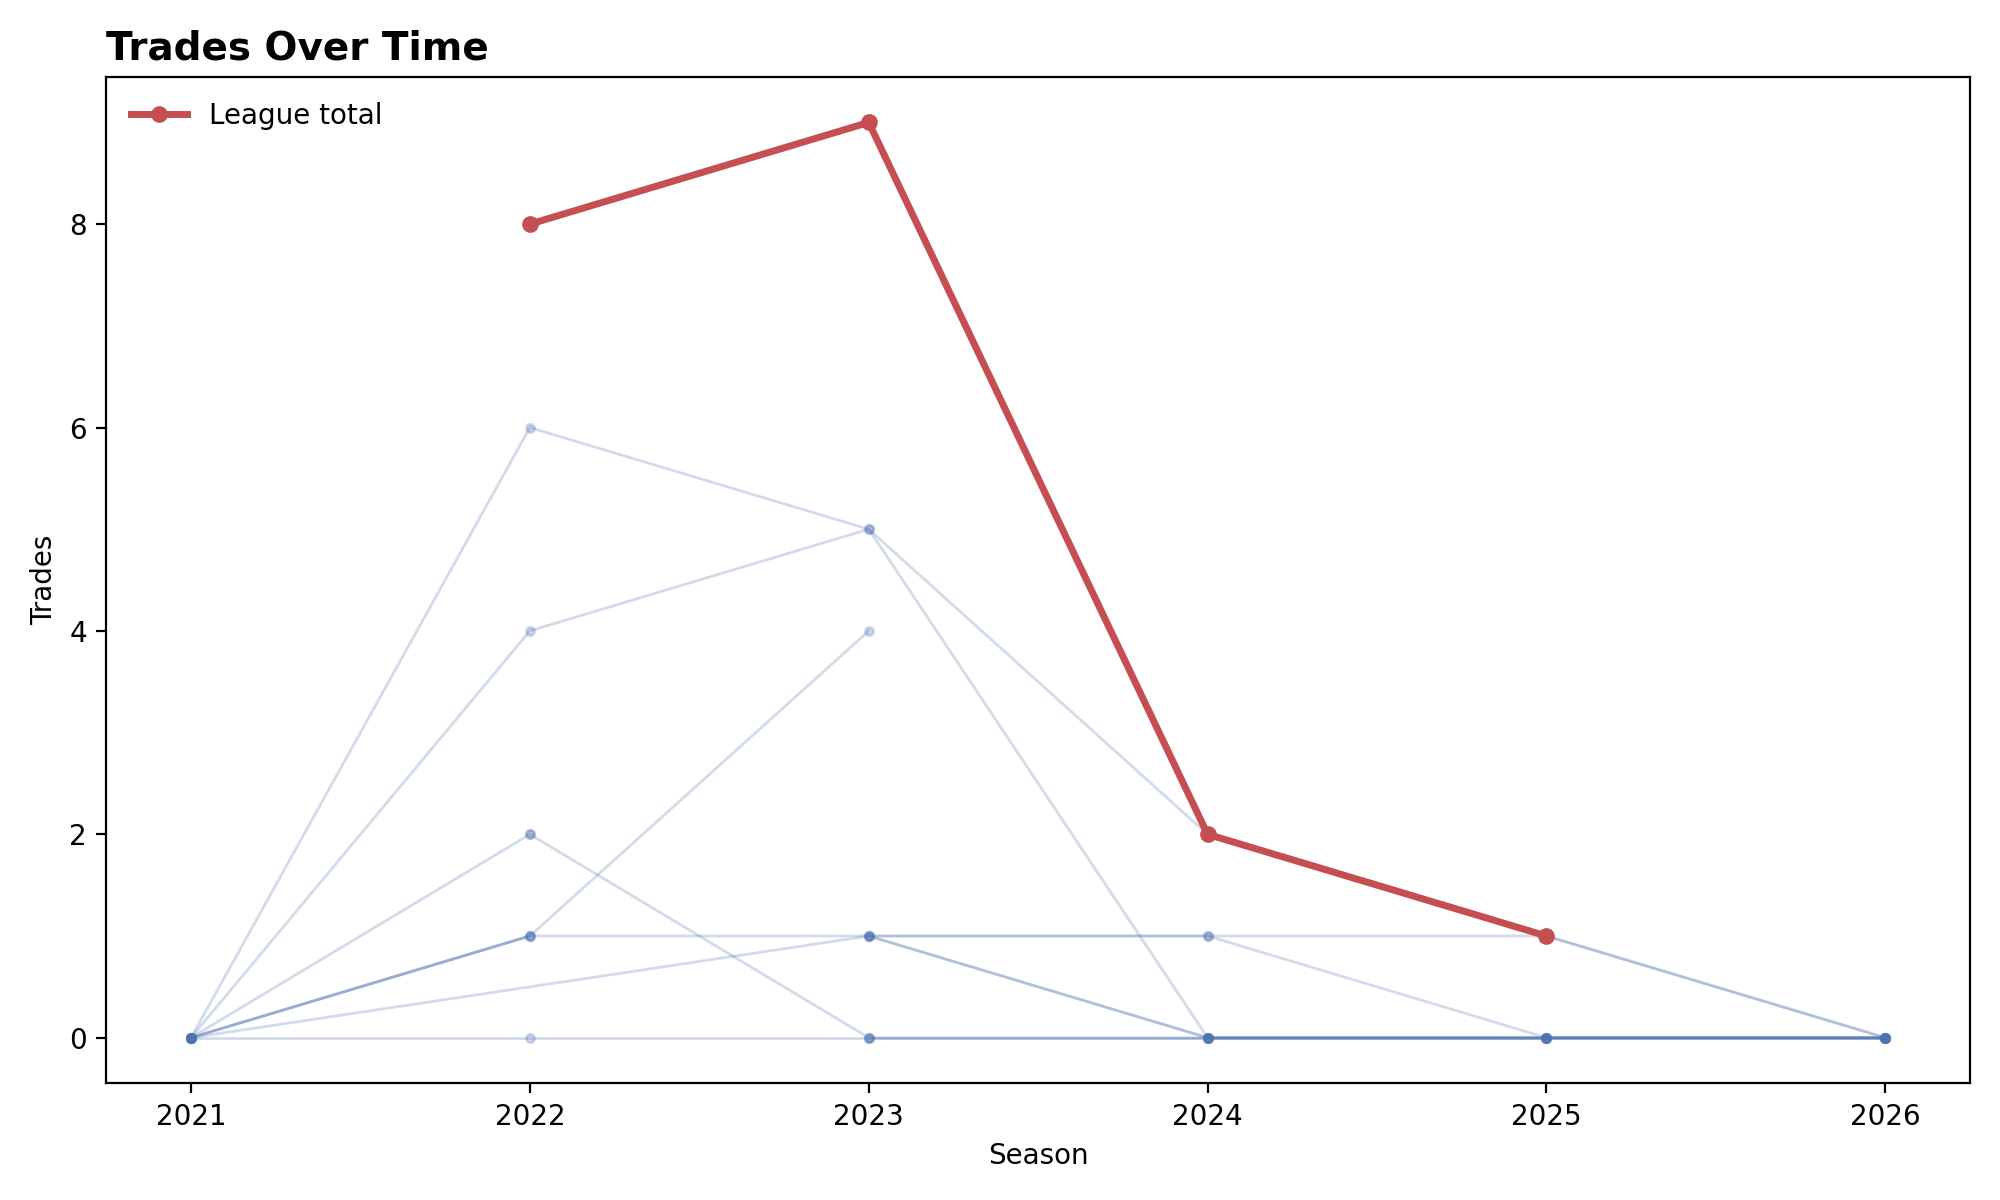

In [9]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/trades_over_time.png"
    )
)  # Trades by season, one line per manager

## Manager x season heatmap

The same manager x season data as the line chart above, as a grid instead. Unlike the line chart, every cell is dense -- a season before or after a manager was in the league renders as the same explicit `0` as a season they rostered but didn't trade in. This league's real 2022 peak -- `nolmacdonald`'s 6 trades in a single season -- renders as the single darkest cell on the grid.

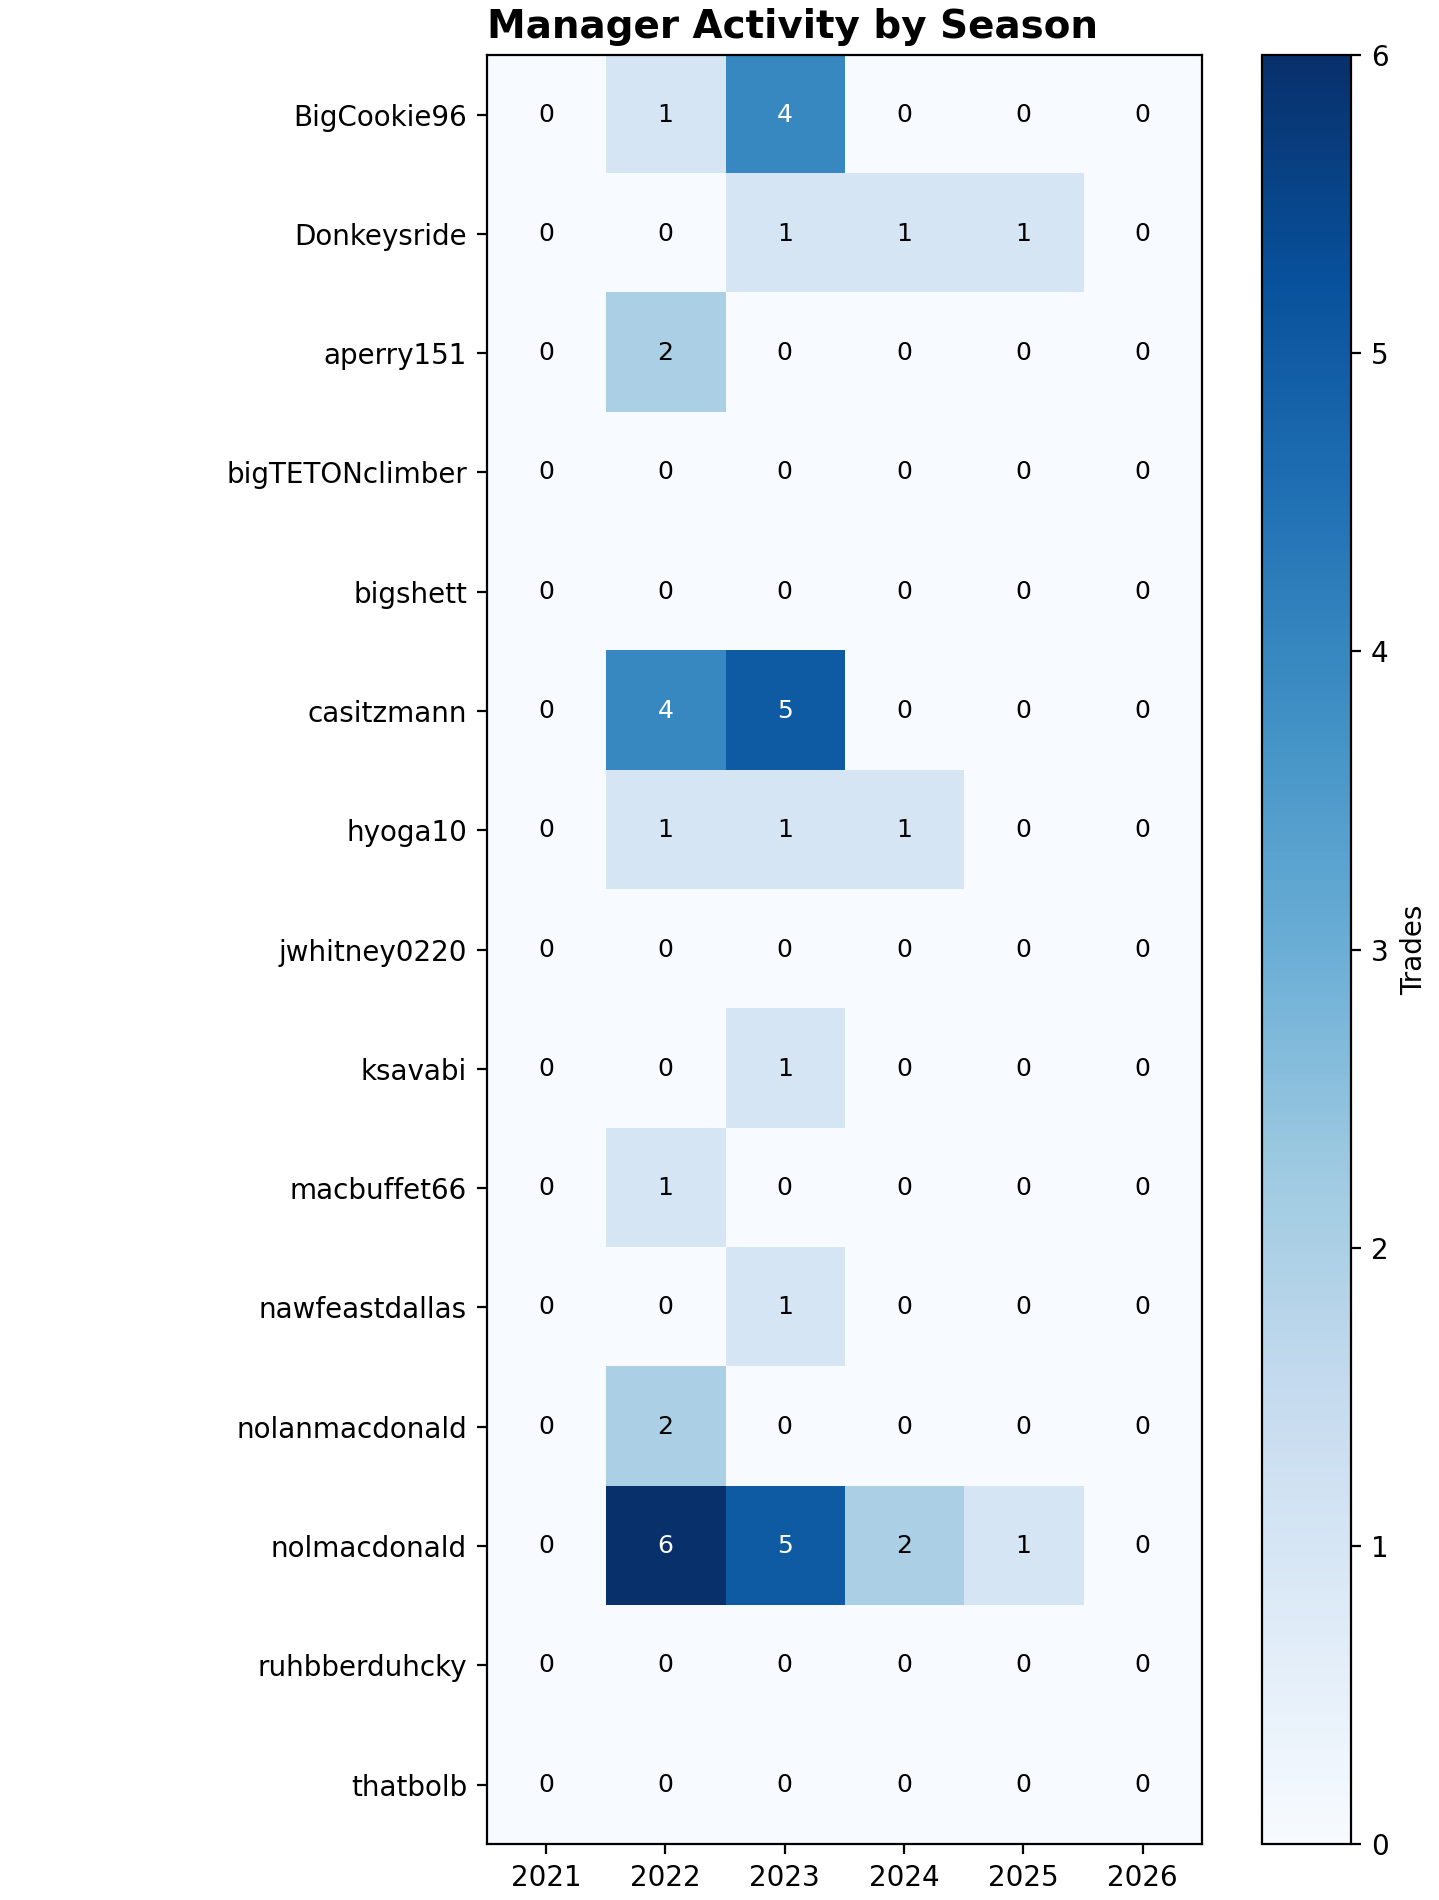

In [10]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/manager_season_heatmap.png"
    )
)  # Manager x season trade heatmap

## Cumulative trade history

A step chart of each manager's running trade total over time, answering "who became the league's most prolific trader, and when did they take the lead." This league's real history: `nolmacdonald` is the all-time leader with 14 of the league's 22 trades, visibly taking the lead in late 2023.

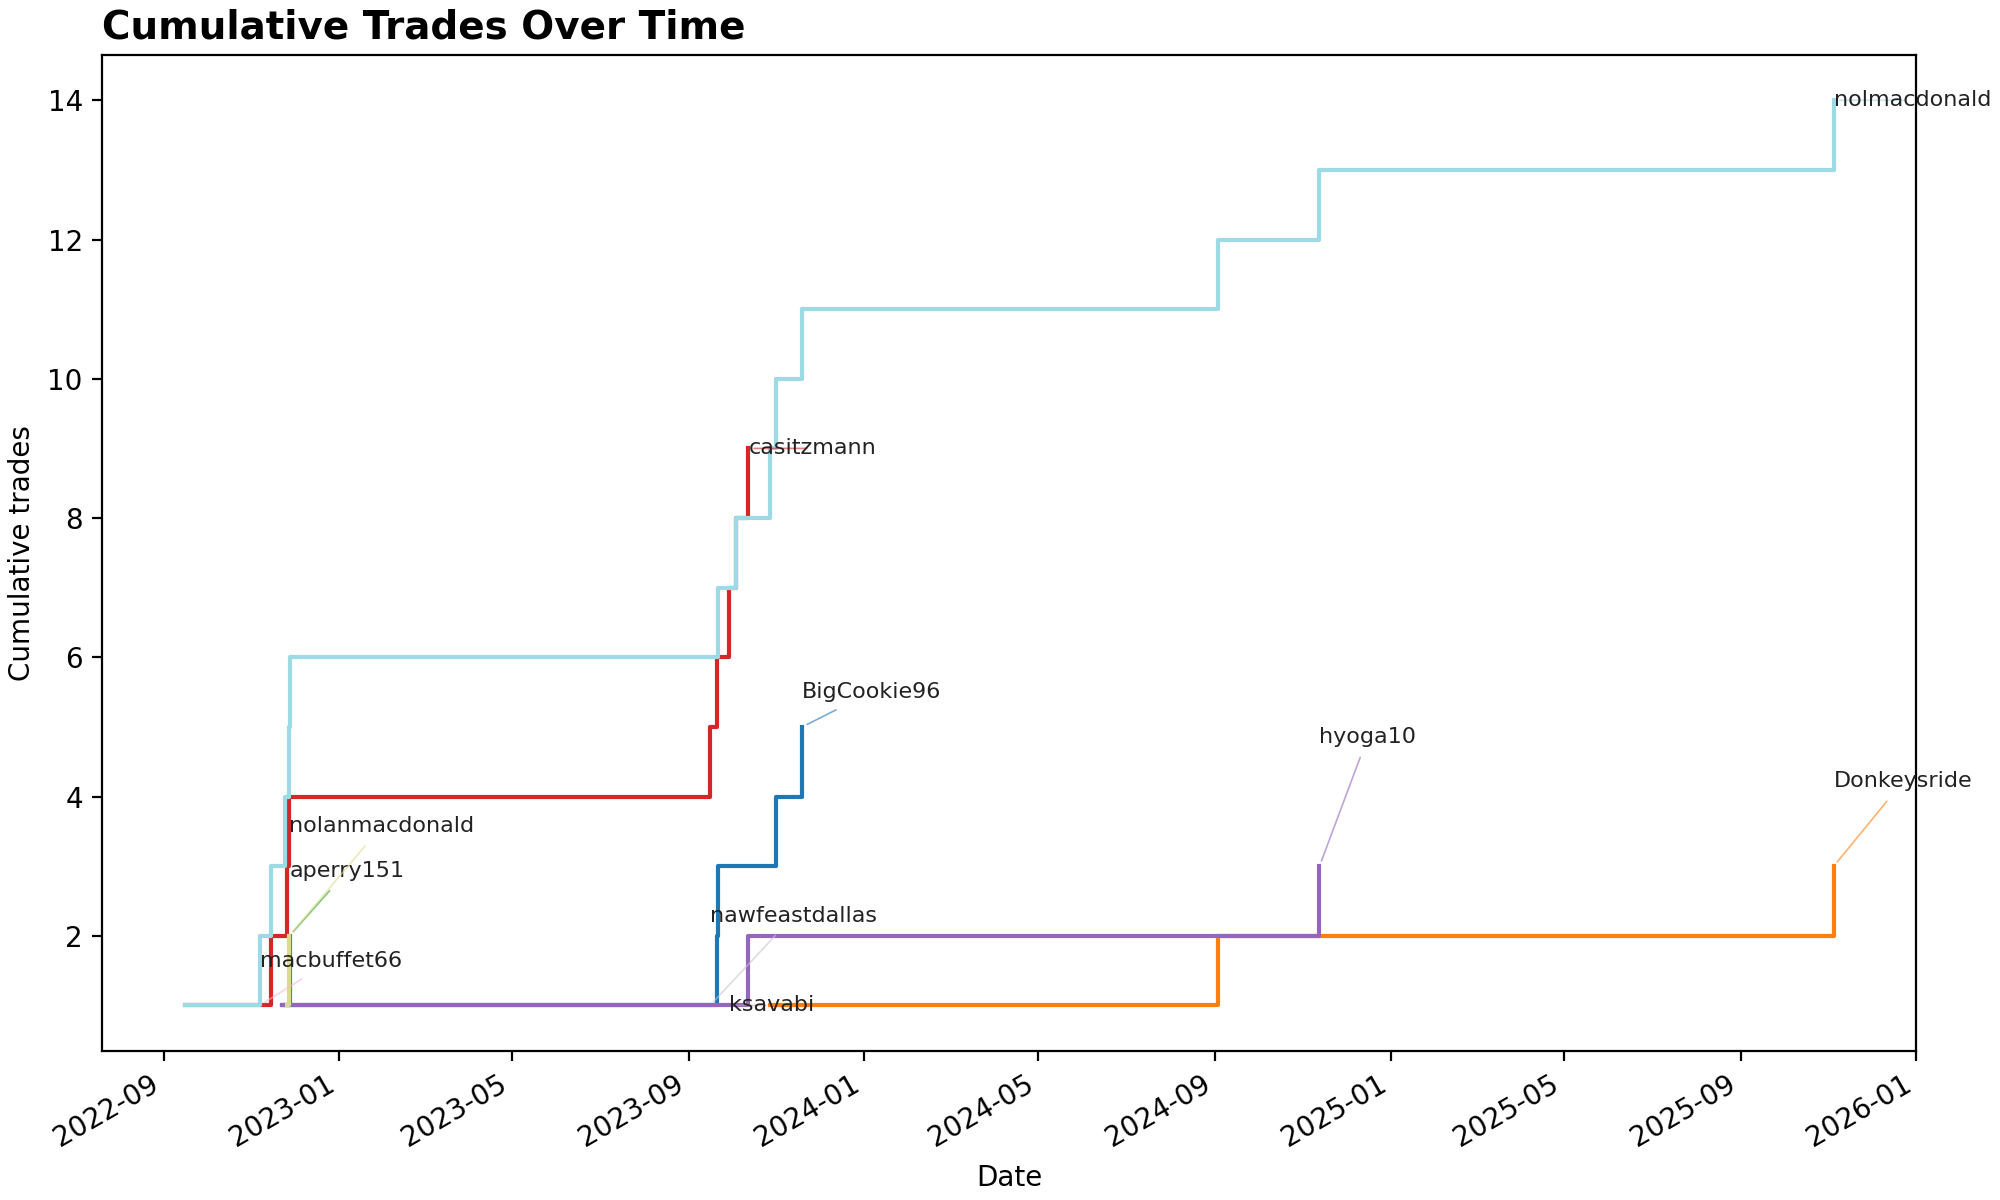

In [11]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/cumulative_trades.png"
    )
)  # Cumulative trades per manager over time

## Trade partner diversity

A scatter plot -- X axis is total trades, Y axis is unique trade partners -- separating a manager who trades widely from one who repeatedly trades with the same one or two people. This league's real 5 zero-trade managers collapse into a single labeled point at the origin rather than five fully-overlapping ones. `nolmacdonald` (14 trades, 7 partners) and `casitzmann` (9 trades, 6 partners) stand out as the widest traders, while `ksavabi`, `macbuffet66`, and `nawfeastdallas` (1 trade, 1 partner each) visibly contrast with `hyoga10` (3 trades, 3 partners) -- the same raw trade count band, opposite diversity.

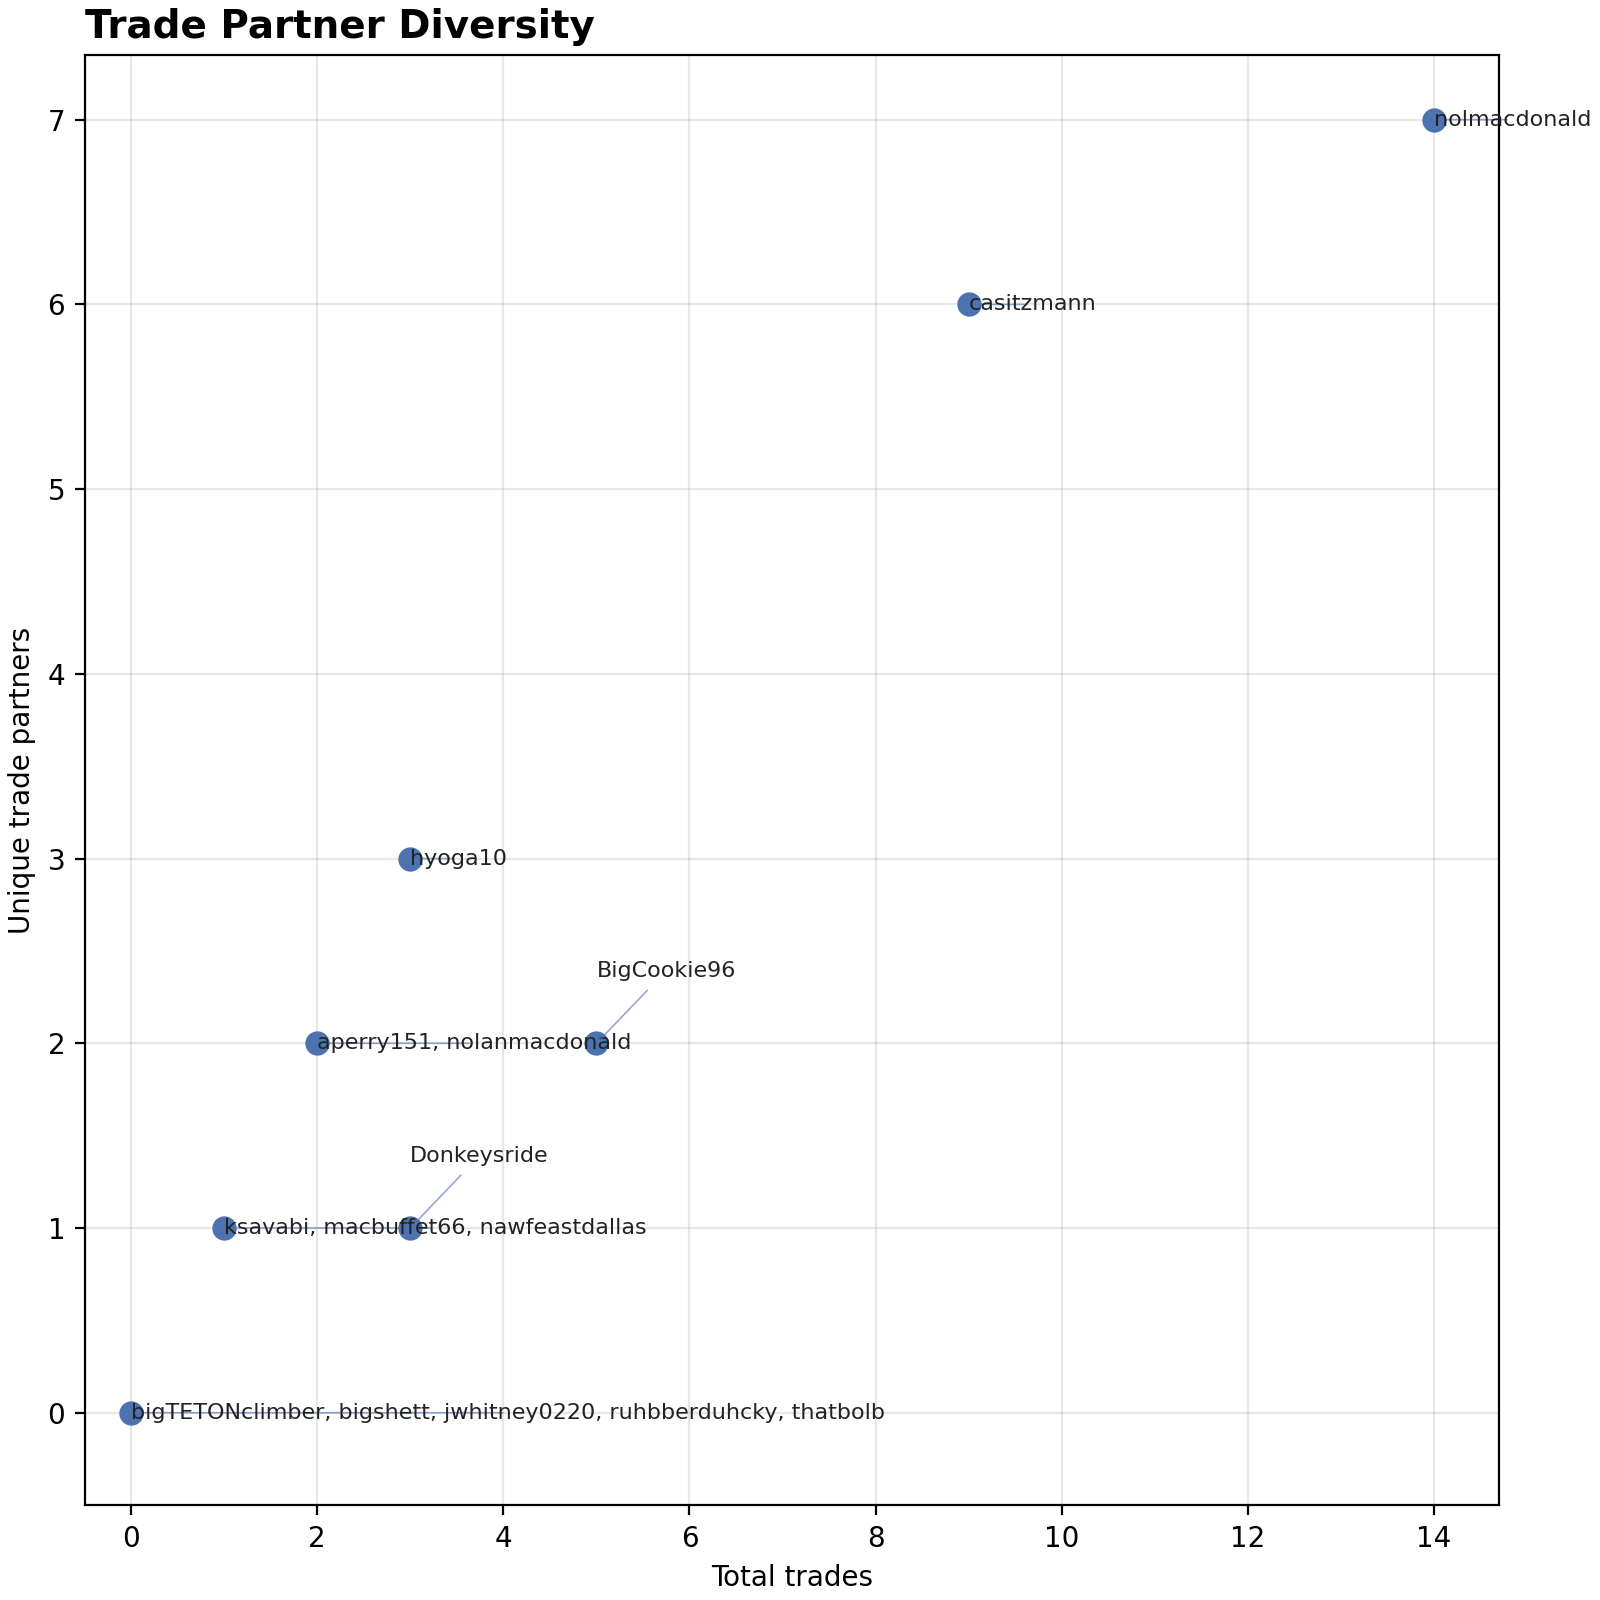

In [12]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/trade_partner_diversity.png"
    )
)  # Total trades vs. unique trade partners

## Reading these charts correctly

Three real details from this exact data apply across every chart above, not just one:

- **A manager needs a resolvable Sleeper display name to appear at all.** Two of this league's 22 real trades have a roster whose owner isn't in that season's user list, so neither trade contributes to any chart.
- **Sleeper allows more than two rosters in a single trade.** Every trade-counting aggregate here de-duplicates by the underlying transaction, not by exploded pairwise edges -- a 3-team trade contributes one trade to each of the three managers involved, not two.
- **Manager identity is a display name, not a stable id**, and this league's data shows exactly why that matters: `nolmacdonald` (14 trades) and `nolanmacdonald` (2 trades, including the three-team trade above) render as two separate managers throughout every chart above. Nothing here merges similar-looking names automatically.

## See Also

- `01_user_guide.ipynb` -- every other `nuclearff` CLI command, including `sleeper fetch-league --transactions`, the data this notebook's command reads.
- [Sleeper API Tutorial](https://nolmacdonald.github.io/nuclearff/sleeper_api_tutorial.html) -- the Sleeper API itself, independent of the CLI.
- [API Reference](https://nolmacdonald.github.io/nuclearff/api/index.html) -- full reference for `nuclearff.sleeper.trades` and `nuclearff.report.trades`.